# Extended Data Figure 2

This notebook includes the analysis code to compare measurements taken from 3D scans to measurement from the Rig2 Cheese3D keypoint estimations.

Before running the notebook, first make sure the anipose project is downloaded (the `ignore_videos=true` flag reduces time required to download):

0. `# python 00-grid-transfer-download.py 'anipose_projects=[20231102-3D-structure-rig2] ignore_videos=true'`

Also make sure the following files are downloaded to the local `mouse-fe-analysis/measurements-data/Watertight_coordinates` directory:
- `B6_points_matrix_watertight.csv`
- `B15_points_matrix_watertight.csv`
- `B20_points_matrix_watertight.csv`
- `B21_points_matrix_watertight.csv`
- `B26_points_matrix_watertight.csv`
- `B31_points_matrix_watertight.csv`
- `B32_points_matrix_watertight.csv`
- `B33_points_matrix_watertight.csv`

In [1]:
%load_ext autoreload
%autoreload 2

# Update path as if notebook was run from top-level repo directory
import os
import sys
pwd = %pwd
if not pwd.endswith('mouse-fe-analysis'):
    sys.path.insert(0, os.path.abspath('..'))
    new_pwd = os.path.abspath(f"{pwd}/..")
    %cd {new_pwd}

/data/disk2/irenenozal/mouse-fe-analysis


/home/irenenozal/micromamba/envs/mouse-fe-analysis/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from pathlib import Path

from fepipeline.features.landmarks import read_3d_data
from fepipeline.anatomy import compute_measurements_df
from labutils.plotting import (sns_setup, landmark_cmap, measurements_cmap) # You can define flat=true/false in landmark_cmap

import warnings
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

# set seaborn theme
sns_setup("paper")
LANDMARK_CMAP = landmark_cmap()
import matplotlib as mpl
mpl.rcParams['lines.markersize'] = 10
plt.close()

In [3]:
COORDINATE_PATHS_RIG2_6CAM = {}
ANIPOSE_BASE = './anipose-projects/20231102-3D-structure-rig2'

for p in Path(ANIPOSE_BASE).glob('*/pose-3d/*.csv'):
    mouse = p.name.split('_')[1]
    if mouse.startswith('B'): # a hack to get rid of phantom csv ._*.csv from mac
        source = 'rig2'
        condition = 'awake' if 'awake' in p.name else 'anes'
        COORDINATE_PATHS_RIG2_6CAM[(mouse, source, condition)] = p

MICE_SHORT = ['B6', 'B15', 'B20', 'B21', 'B26', 'B31', 'B32', 'B33']

coord_data_rig2_6cam = {k: read_3d_data(v.parent.parent.as_posix()) 
                        for k,v in COORDINATE_PATHS_RIG2_6CAM.items()}

### 1. Read 3D scan raw data (keypoints)

In [4]:
import glob
def read_3d_scan(data_dir):
    """Load 3D landmark data from Anipose.

    ### Arguments
    - `data_dir`: the Anipose directory for the 3d scan points to load

    ### Returns
    An array of 3D data where each row is a landmark containing
    the X, Y, Z coordinates determined through the 3D scan
    """
    data = pd.read_csv(data_dir)
    scan_coords = {} #landmark by (x,y,z)
    # print('This list of landmarks should follow the same order as the list above except the excluded points')
    for r in coord_data_rig2_6cam['B6','rig2','anes'].keys(): #Keys should be the same for every mouse
        for s in data['Point']:
            landmark_name = s
            if s == 'whiskerA(l)':
                landmark_name = 'pad(top)(left)'
            elif s == 'whiskerA(r)':
                landmark_name = 'pad(top)(right)'
            elif s == 'whiskerB(l)':
                landmark_name = 'pad(side)(left)'
            elif s == 'whiskerB(r)':
                landmark_name = 'pad(side)(right)'
            elif s == 'whiskerC':
                landmark_name = 'pad(center)'
            
            if landmark_name == r:
                #print(r)
                point = data.loc[data['Point'] == s, ['X', 'Y', 'Z']].values
                scan_coords[r] = point

    missing = ['lowerlip', 'upperlip(left)', 'upperlip(right)']
    for m in missing:
        if m not in scan_coords.keys():
            scan_coords[m] = np.zeros([1,3])

    return scan_coords


SCAN_DIRS = {mouse: f"./measurements-data/Watertight_coordinates/{mouse}_points_matrix_watertight.csv"
          for mouse in MICE_SHORT}

scan_coords = {(m, 'scan', 'anes'): read_3d_scan(SCAN_DIRS[m]) for m in MICE_SHORT}

In [5]:
LANDMARK_CMAP_MEAS_OLD = measurements_cmap(spread = 0)

In [6]:
# The goal of this cell is to hardcode the ear angle & mouth area color without disturbing the rest of colors
M_NAMES = {}
COLORS = {}
for i, s in enumerate(LANDMARK_CMAP_MEAS_OLD):
    if i == 0:
        for m, n in LANDMARK_CMAP_MEAS_OLD[i].items():
            M_NAMES[m] = n #hard-code the name
            if m == 'eye-width':
                M_NAMES['ear-angle'] = ["ear-angle-left",  "ear-angle-right"]
    else:
        for l,c in LANDMARK_CMAP_MEAS_OLD[i].items():
            COLORS[l] = c
            if l=='eye-width-right': #hard-code the color
                COLORS['ear-angle-left'] = np.array([146, 114, 37, 255])/255 #Hard code ear angle color
                COLORS['ear-angle-right'] = np.array([146, 114, 37, 255])/255

LANDMARK_CMAP_MEAS = (M_NAMES, COLORS)
LANDMARK_CMAP_MEAS[1]['mouth-area'] = np.array([208, 105, 80, 255])/255 #Hard-coding mouth color
        

### 2. Format data accordingly

In [7]:
def rig_coords_avs(data, excluded):
    rig_coords = [] #landmark (remember to remove mouth and ref post) by (x,y,z)
    for _, l in enumerate(data.keys()):
        if l not in excluded:
            rig_coords.append(np.mean(data[l], axis = 0))
    
    return np.array(rig_coords)

excluded = ['ref(head-post)', 'lowerlip', 'upperlip(left)', 'upperlip(right)']
rig_coords_mice = {m: rig_coords_avs(coord_data_rig2_6cam[m,'rig2','anes'], excluded) 
                   for m in MICE_SHORT}

In [8]:
# Simplified dictionary without landmark keywords
def flatten_scan_coords(scan_coords_mouse, excluded):
    scan_coords_mouse_flat = []
    for i in scan_coords_mouse.items():
        if i[0] not in excluded:
            # print(i[0])
            scan_coords_mouse_flat.append(i[1][0])

    return np.array(scan_coords_mouse_flat)

scan_coords_flat = {m: flatten_scan_coords(scan_coords[(m, 'scan', 'anes')], excluded) 
                    for m in MICE_SHORT}


In [9]:
# Should be the same size
print(scan_coords_flat['B31'].shape)
print(rig_coords_mice['B31'].shape)

(24, 3)
(24, 3)


We will do least squares to express the 3D data in the same reference system as the rig model data. 

I am using the 3D scan as reference and doing least squares on the rig model data. I am doing this way so that I can use the output for overlapping it on the 3D scan model (labmesh software)

In [10]:
# # Now we express the landmarks coordinates from the 3D scan 
# # in the same frame of reference as the coordinates from our rig model
# # We will use least squares. 
# # Firs, let's normalize the data for safer least squares
# def z_score(raw_data):
#     mean = np.mean(raw_data, 0, keepdims=True)
#     sigma = 1 #np.std(raw_data, 0, keepdims=True)
#     #sigma[sigma == 0] = 1
#     return (raw_data-mean)/sigma

# # This will be used after the least sqares, to go back to real units
# def un_zscore(raw_data, z_score_data): #Undo z-scoring for plotting as a sanity check - there is no deformation
#     mean = 0 #np.mean(raw_data, 0, keepdims=True) 
#     sigma = 1 #np.std(raw_data, 0, keepdims=True)
#     #sigma[sigma == 0] = 1
#     return z_score_data*sigma + mean

# # Assuming rotation AND translation may be necessary to align the two sets of points, 
# # we need to add a column of 1's to the array containing the coordinates from the 3D scan
# scan_coords_mice_zscore = {}
# rig_coords_mice_zscore = {}
# for m in MICE_SHORT:
#     scan_coords_mice_zscore[m] = z_score(scan_coords_flat[m])
#     rig_coords_mice_zscore[m] = np.hstack((z_score(rig_coords_mice[m]), 
#                                            np.ones([rig_coords_mice[m].shape[0],1]))) #Add a column of ones here for translation (probably not needed if you zscore)
# #print(scan_coords_mice[m].shape)

# # Now the data is ready for least squares:
# transform_x_mice = {m: np.linalg.lstsq(rig_coords_mice_zscore[m], scan_coords_mice_zscore[m]) 
#                     for m in MICE_SHORT}

# rig_coords_mice_transform = {m: un_zscore(scan_coords_flat[m], np.dot(rig_coords_mice_zscore[m], transform_x_mice[m][0])) 
#                               for m in MICE_SHORT}

In [11]:
# ALTERNATIVE TO THE CELL ABOVE
# TRANSFORMING INTO THE MODEL COORDINATES INSTEAD
# DO NOT RUN BOTH CELLS
# Now we express the landmarks coordinates from the 3D scan 
# in the same frame of reference as the coordinates from our rig model
# We will use least squares. 
# Firs, let's center the data for safer least squares
def centered(raw_data):
    mean = np.mean(raw_data, 0, keepdims=True)
    print(mean)
    return raw_data-mean

scan_coords_mice_centered = {}
rig_coords_mice_centered = {}
for m in MICE_SHORT:
    #Add a column of ones to the scan points for translation (not needed if you centered)
    # scan_coords_mice_centered[m] = np.hstack((centered(scan_coords_flat[m]), 
    #                                        np.ones([scan_coords_flat[m].shape[0],1]))) 
    scan_coords_mice_centered[m] = centered(scan_coords_flat[m])
    rig_coords_mice_centered[m] = centered(rig_coords_mice[m])

# Now the data is ready for least squares:
transform_x_mice = {m: np.linalg.lstsq(scan_coords_mice_centered[m], rig_coords_mice_centered[m]) 
                    for m in MICE_SHORT}

scan_coords_mice_transform = {m: np.dot(scan_coords_mice_centered[m], transform_x_mice[m][0]) 
                              for m in MICE_SHORT}

[[-55.71200304  24.08553513 384.08038542]]
[[ 0.58275286  2.17151846 13.59652941]]
[[-57.24262746  23.22189229 382.74503083]]
[[ 1.00538669  1.85958056 11.83392263]]
[[-57.62442717  23.66175025 382.76413792]]
[[ 0.75267367 -0.17347179 10.06594892]]
[[-55.43864571  24.22638204 384.23562042]]
[[168.59631779  17.97331402  -8.48280517]]
[[-55.31884838  24.56266567 383.96395375]]
[[ 1.16715787  0.84185036 11.85099651]]
[[-55.76484704  25.19021021 383.78562375]]
[[-0.81415625 -0.98101904 12.95386884]]
[[-58.18913958  28.16546367 383.60268333]]
[[-0.01542154  0.8528267  11.9616214 ]]
[[-55.92228433  23.98411204 383.87251333]]
[[-0.63752437  0.30110895 11.50242911]]


/tmp/ipykernel_141369/3004049385.py:23: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  transform_x_mice = {m: np.linalg.lstsq(scan_coords_mice_centered[m], rig_coords_mice_centered[m])


In [12]:
FLAT_LANDMARK_CMAP = landmark_cmap(flat=True)

In [13]:
def plot_scan_rig_comparison(scan_coords_mice_transform, rig_coords_mice_zscore,
                             mouse, init_view, excluded):
        fig, axs = plt.subplots(nrows=1,
                                ncols=1,
                                subplot_kw={"projection": "3d"},
                                figsize=(8, 8),
                                dpi=200,
                                constrained_layout=True)
        i = 0
        for l in coord_data_rig2_6cam[mouse,'rig2','anes'].keys():
                if l not in excluded:
                        # if l == 'ear(tip)(right)':
                        #         i += 1
                        #         continue #skip this iteration of the loop
                        axs.scatter(scan_coords_mice_transform[mouse][i,0],
                                scan_coords_mice_transform[mouse][i,1],
                                scan_coords_mice_transform[mouse][i,2],
                                color=FLAT_LANDMARK_CMAP[1][l],
                                label = l, s=80, edgecolors='black')
                        axs.scatter(rig_coords_mice_zscore[mouse][i,0],
                                rig_coords_mice_zscore[mouse][i,1],
                                rig_coords_mice_zscore[mouse][i,2],
                                color=FLAT_LANDMARK_CMAP[1][l],
                                marker = '*', s=110, edgecolors='black')
                                #label = l)
                        axs.plot([scan_coords_mice_transform[mouse][i,0], rig_coords_mice_zscore[mouse][i,0]], #X coordinate
                                [scan_coords_mice_transform[mouse][i,1], rig_coords_mice_zscore[mouse][i,1]],  #Y coordinate
                                [scan_coords_mice_transform[mouse][i,2], rig_coords_mice_zscore[mouse][i,2]],  #Z coordinate
                                color='black', linestyle='dotted')
                        i += 1
        
        axs.view_init(*init_view)
        axs.set_title(f'{mouse} - Cheese3D model (*) vs 3D scan (o)')
        axs.legend(fontsize = 8, loc='center right', bbox_to_anchor=(1.2, 0.5))
        # Aesthetics
        axs.grid(False)
        axs.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        axs.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        axs.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        axs.set_xticks([])
        axs.set_yticks([])
        axs.set_zticks([])

        return fig, axs

### 3. Figure

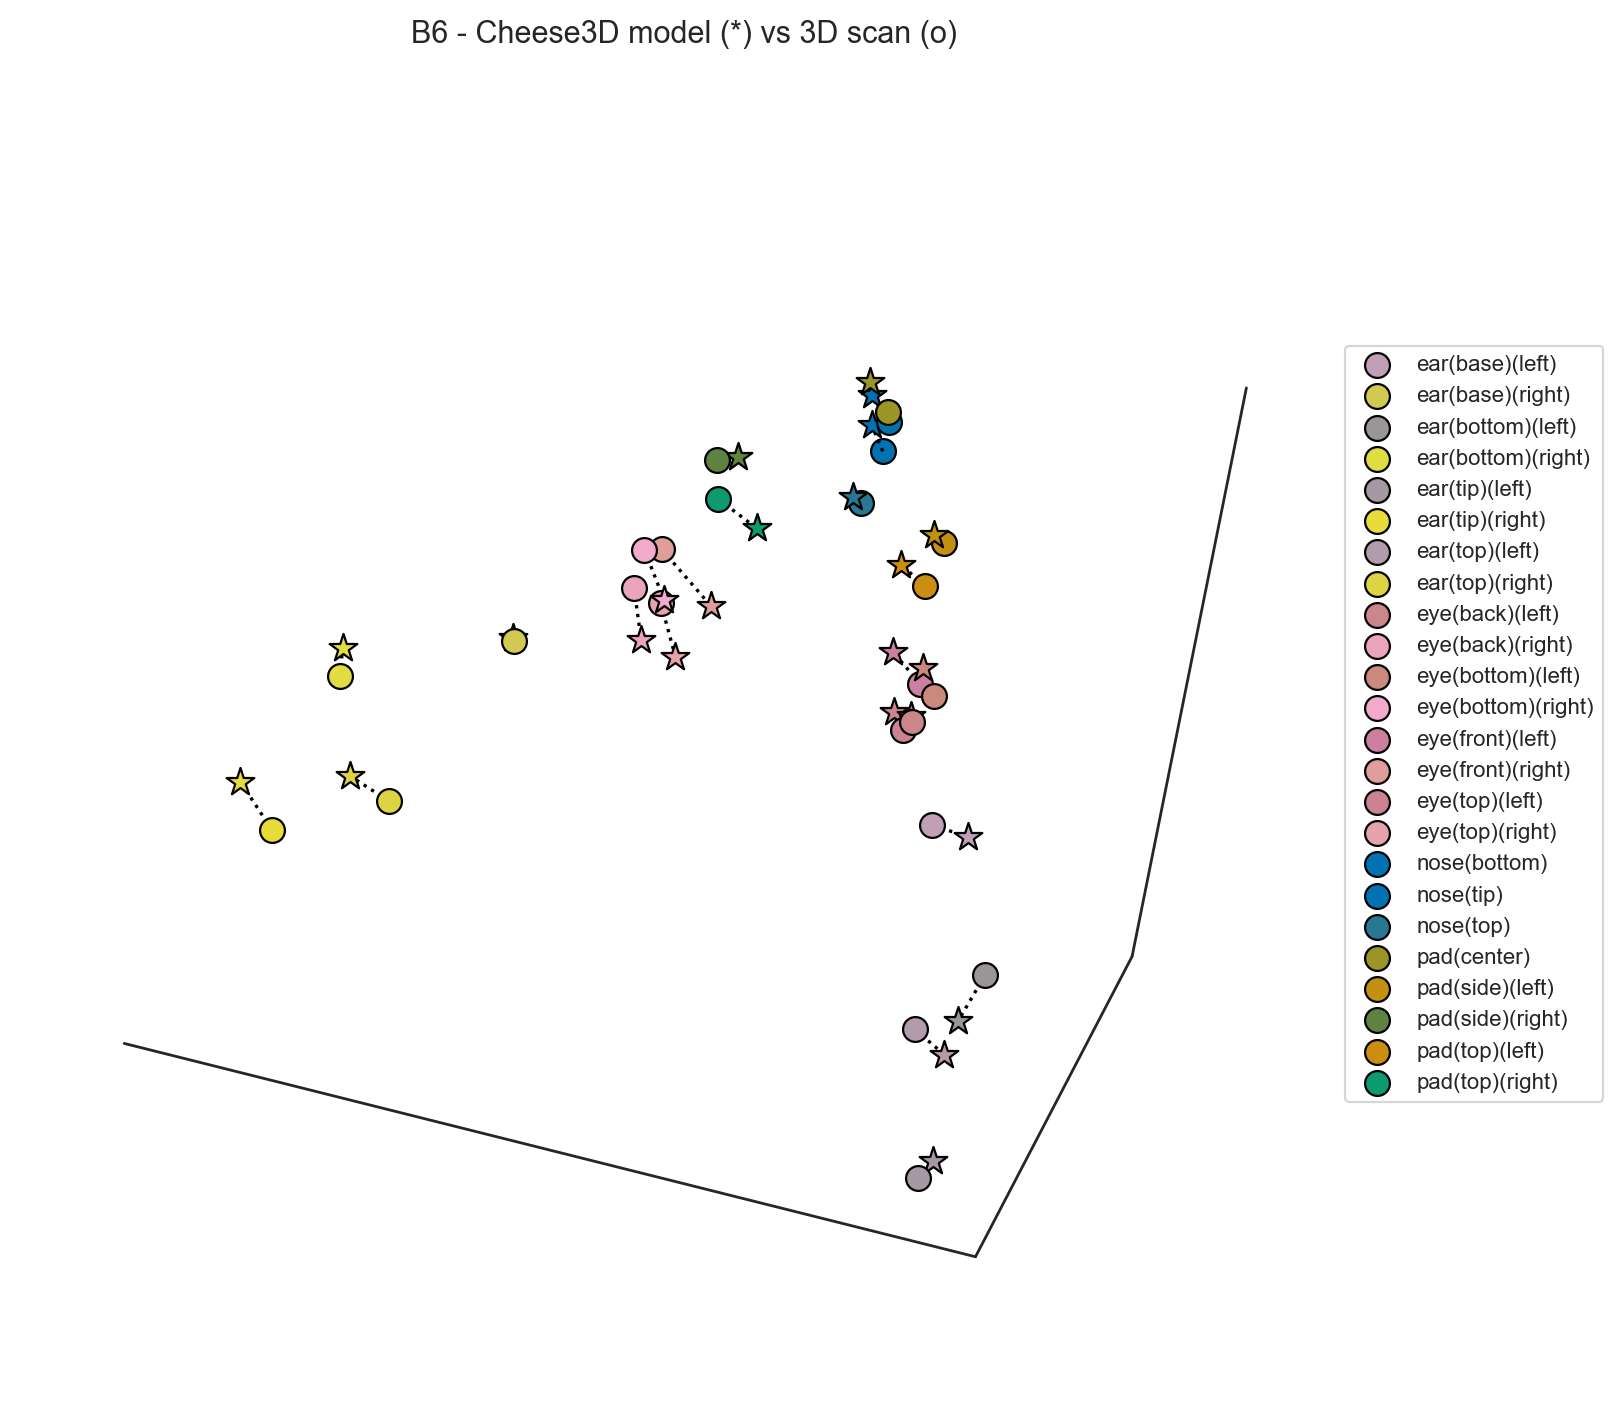

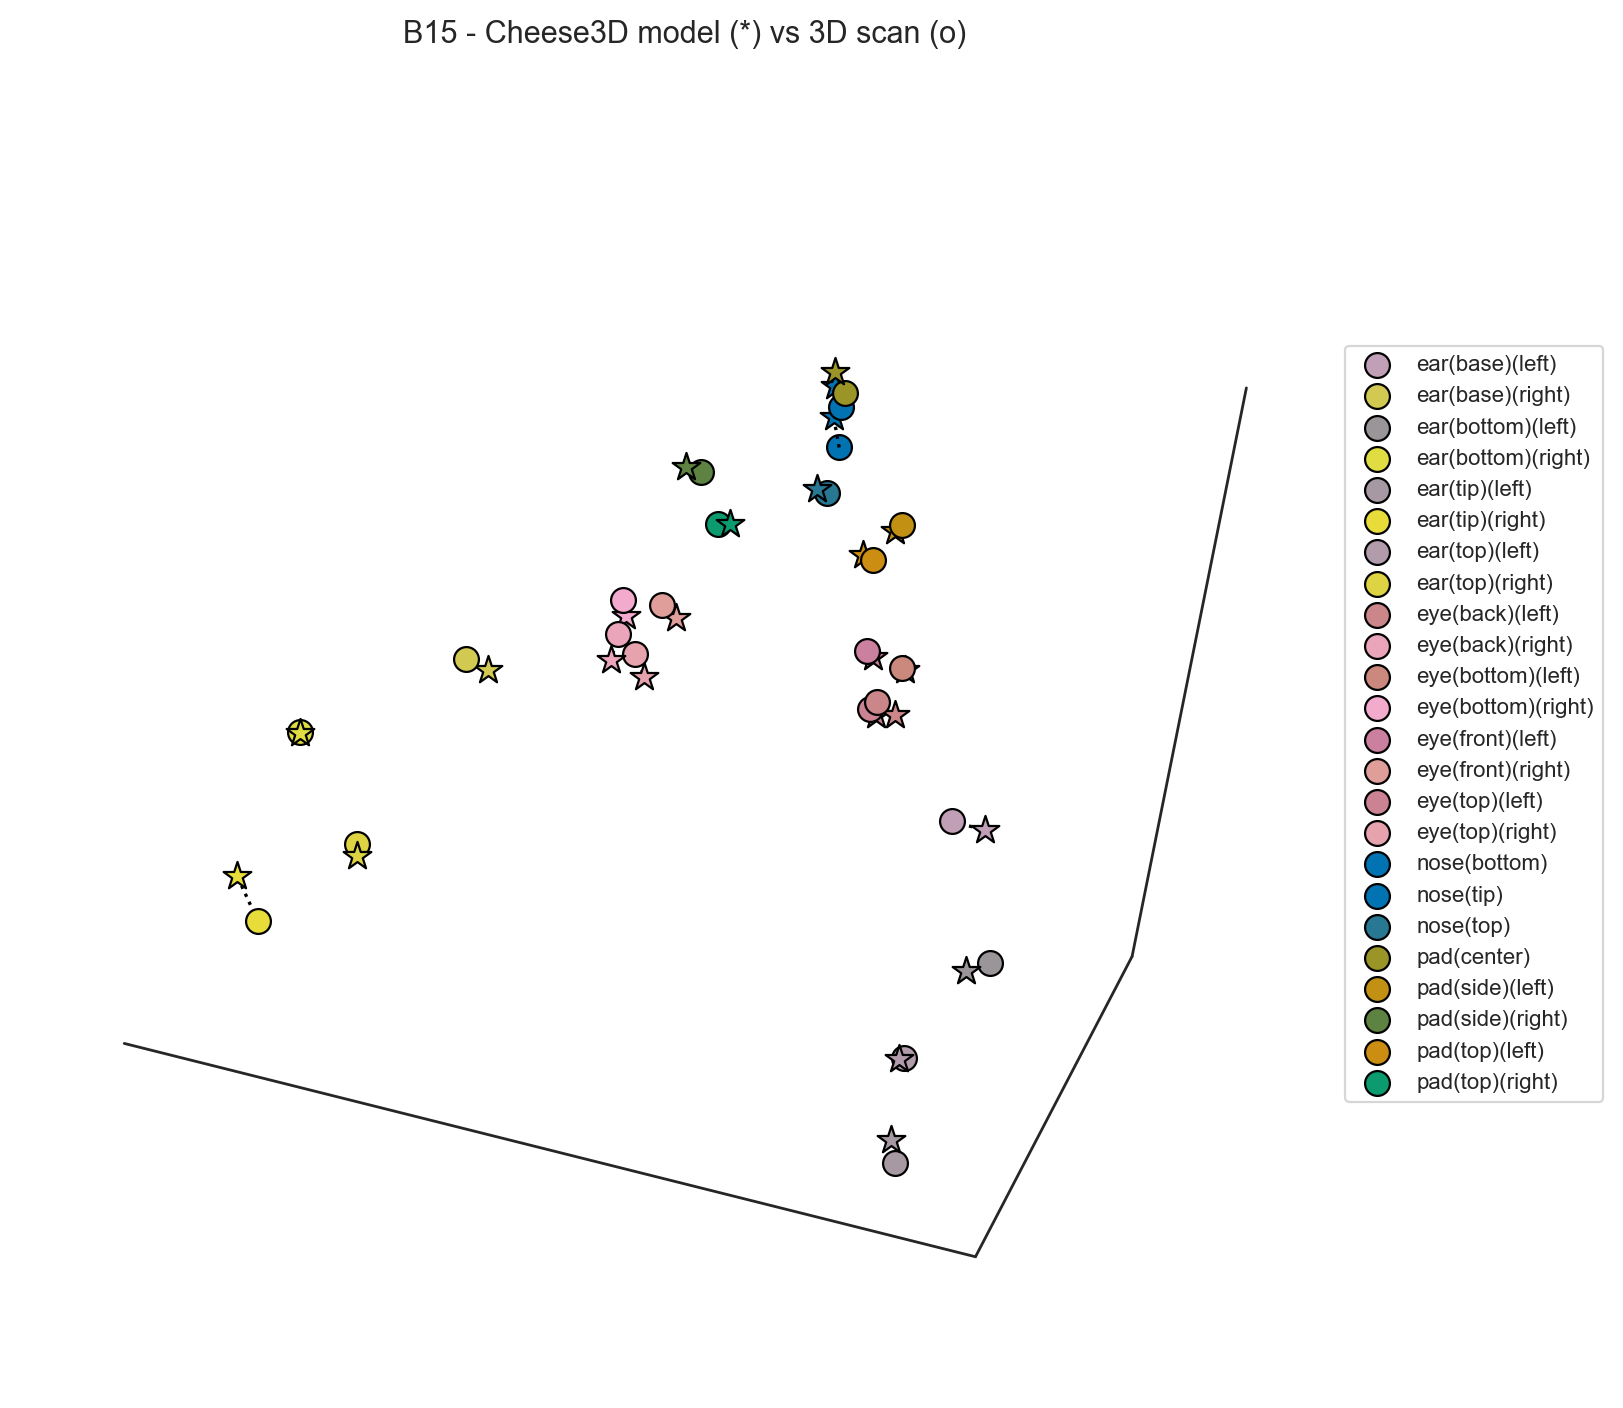

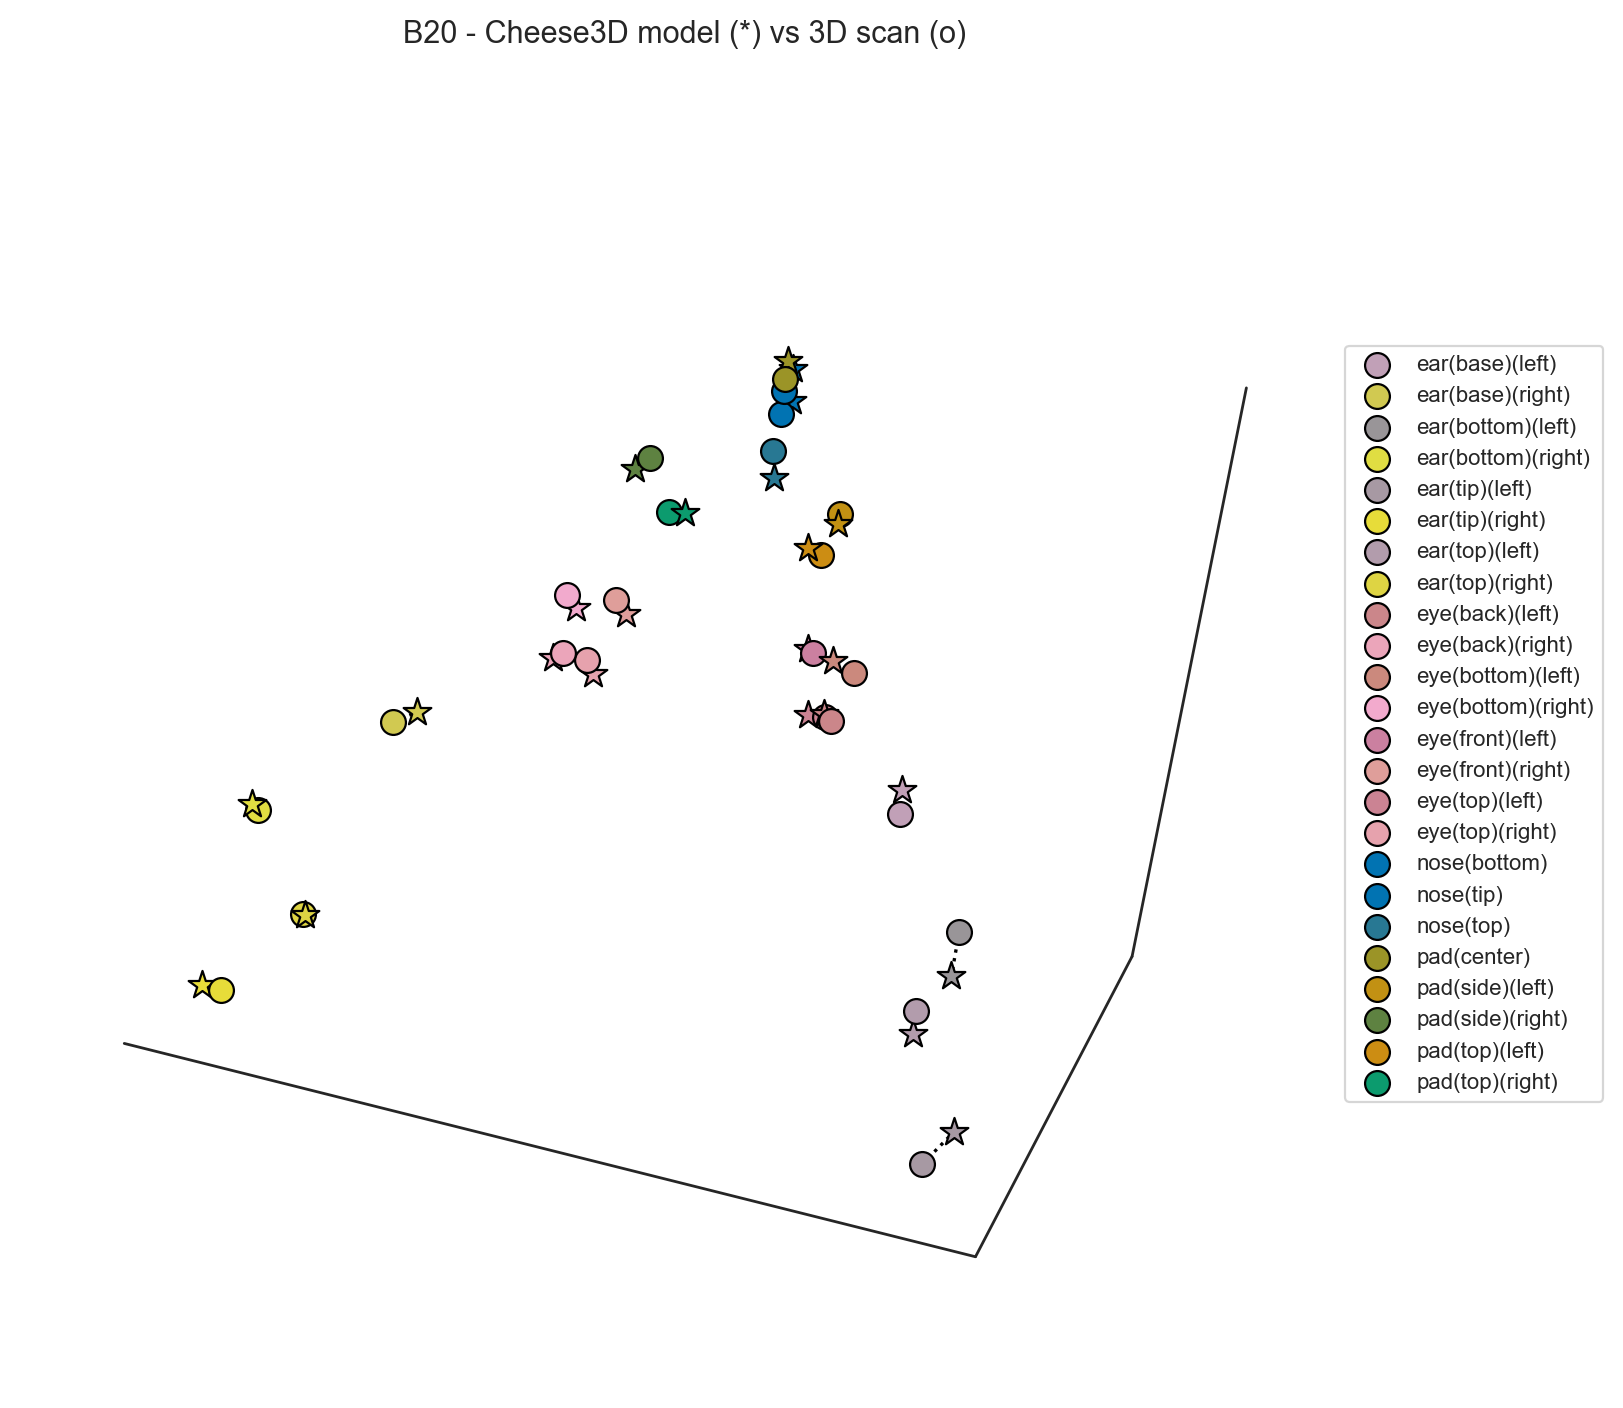

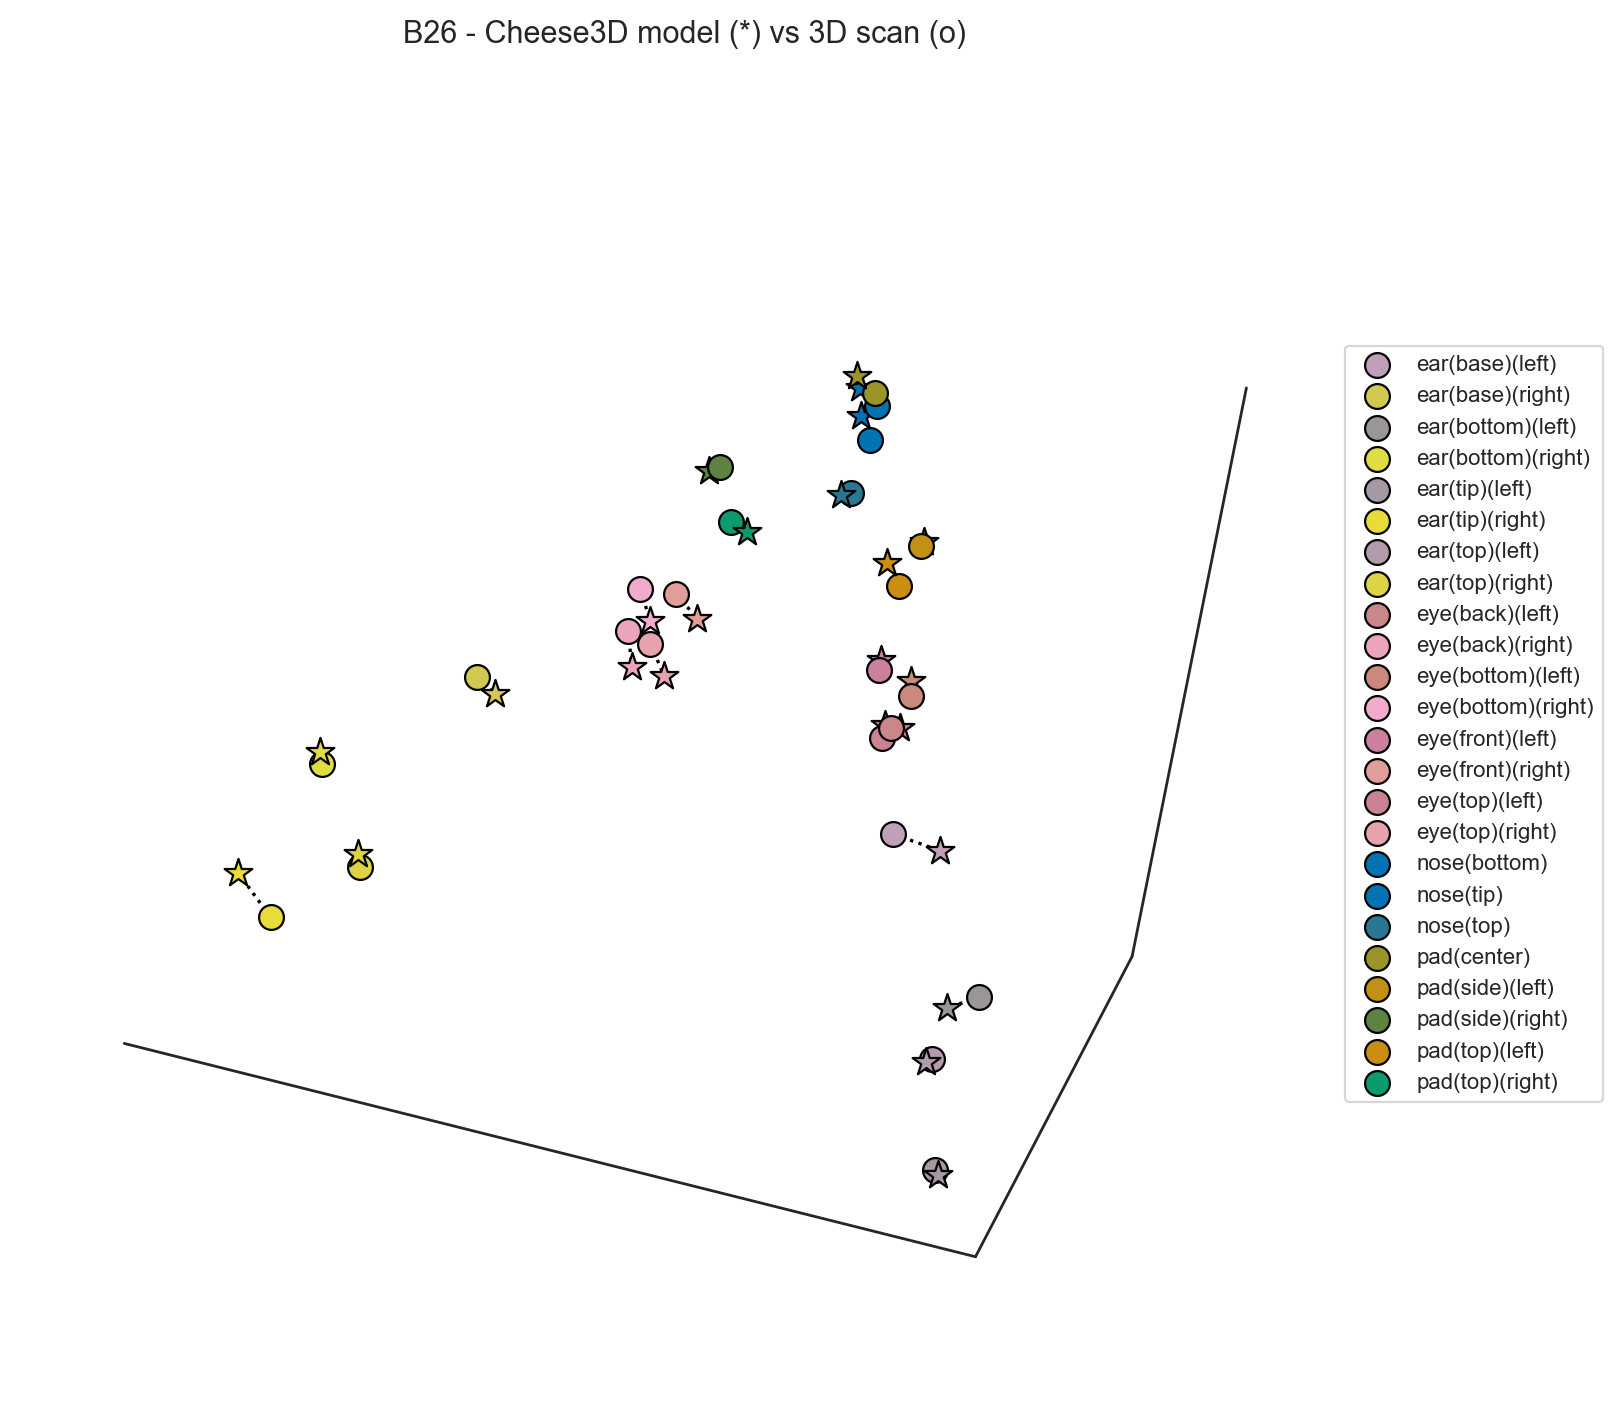

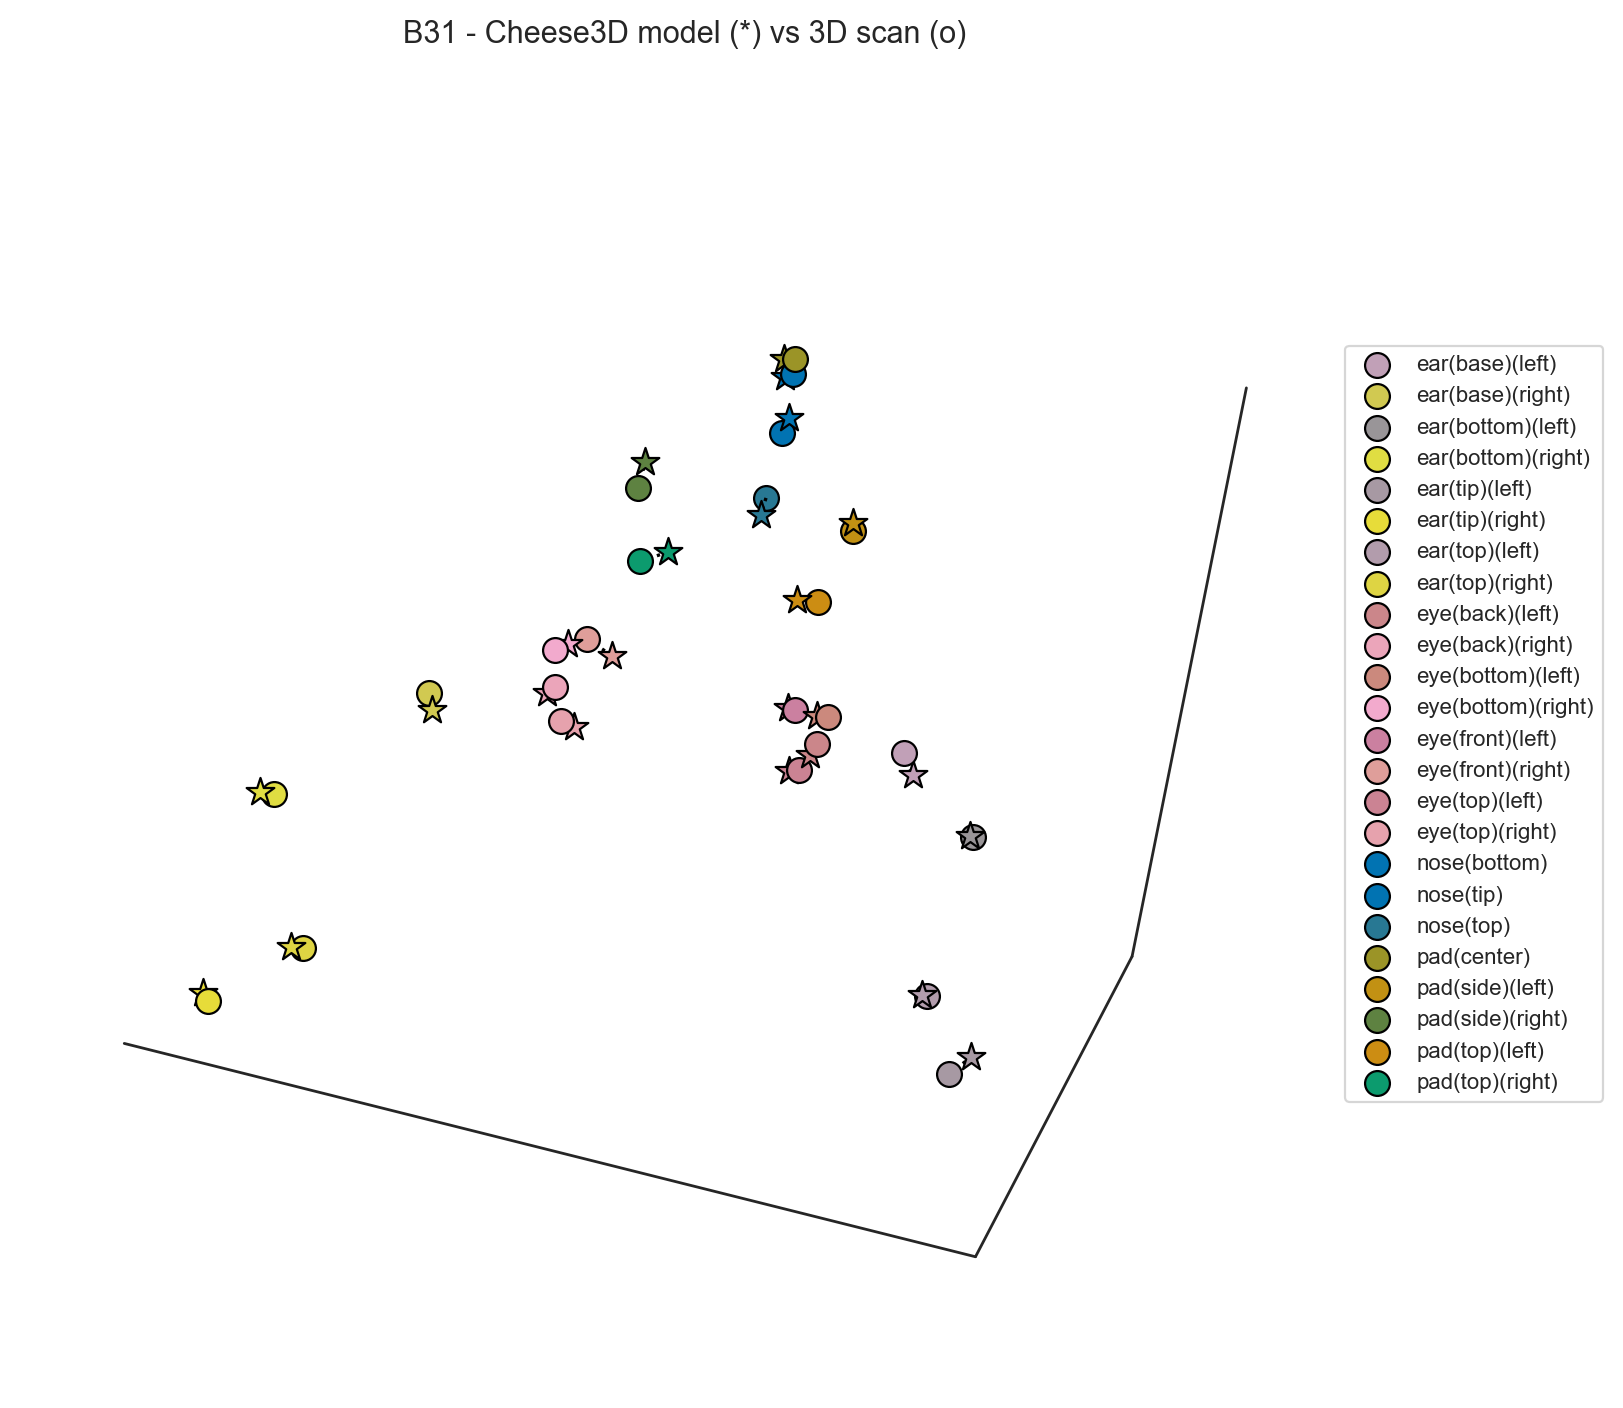

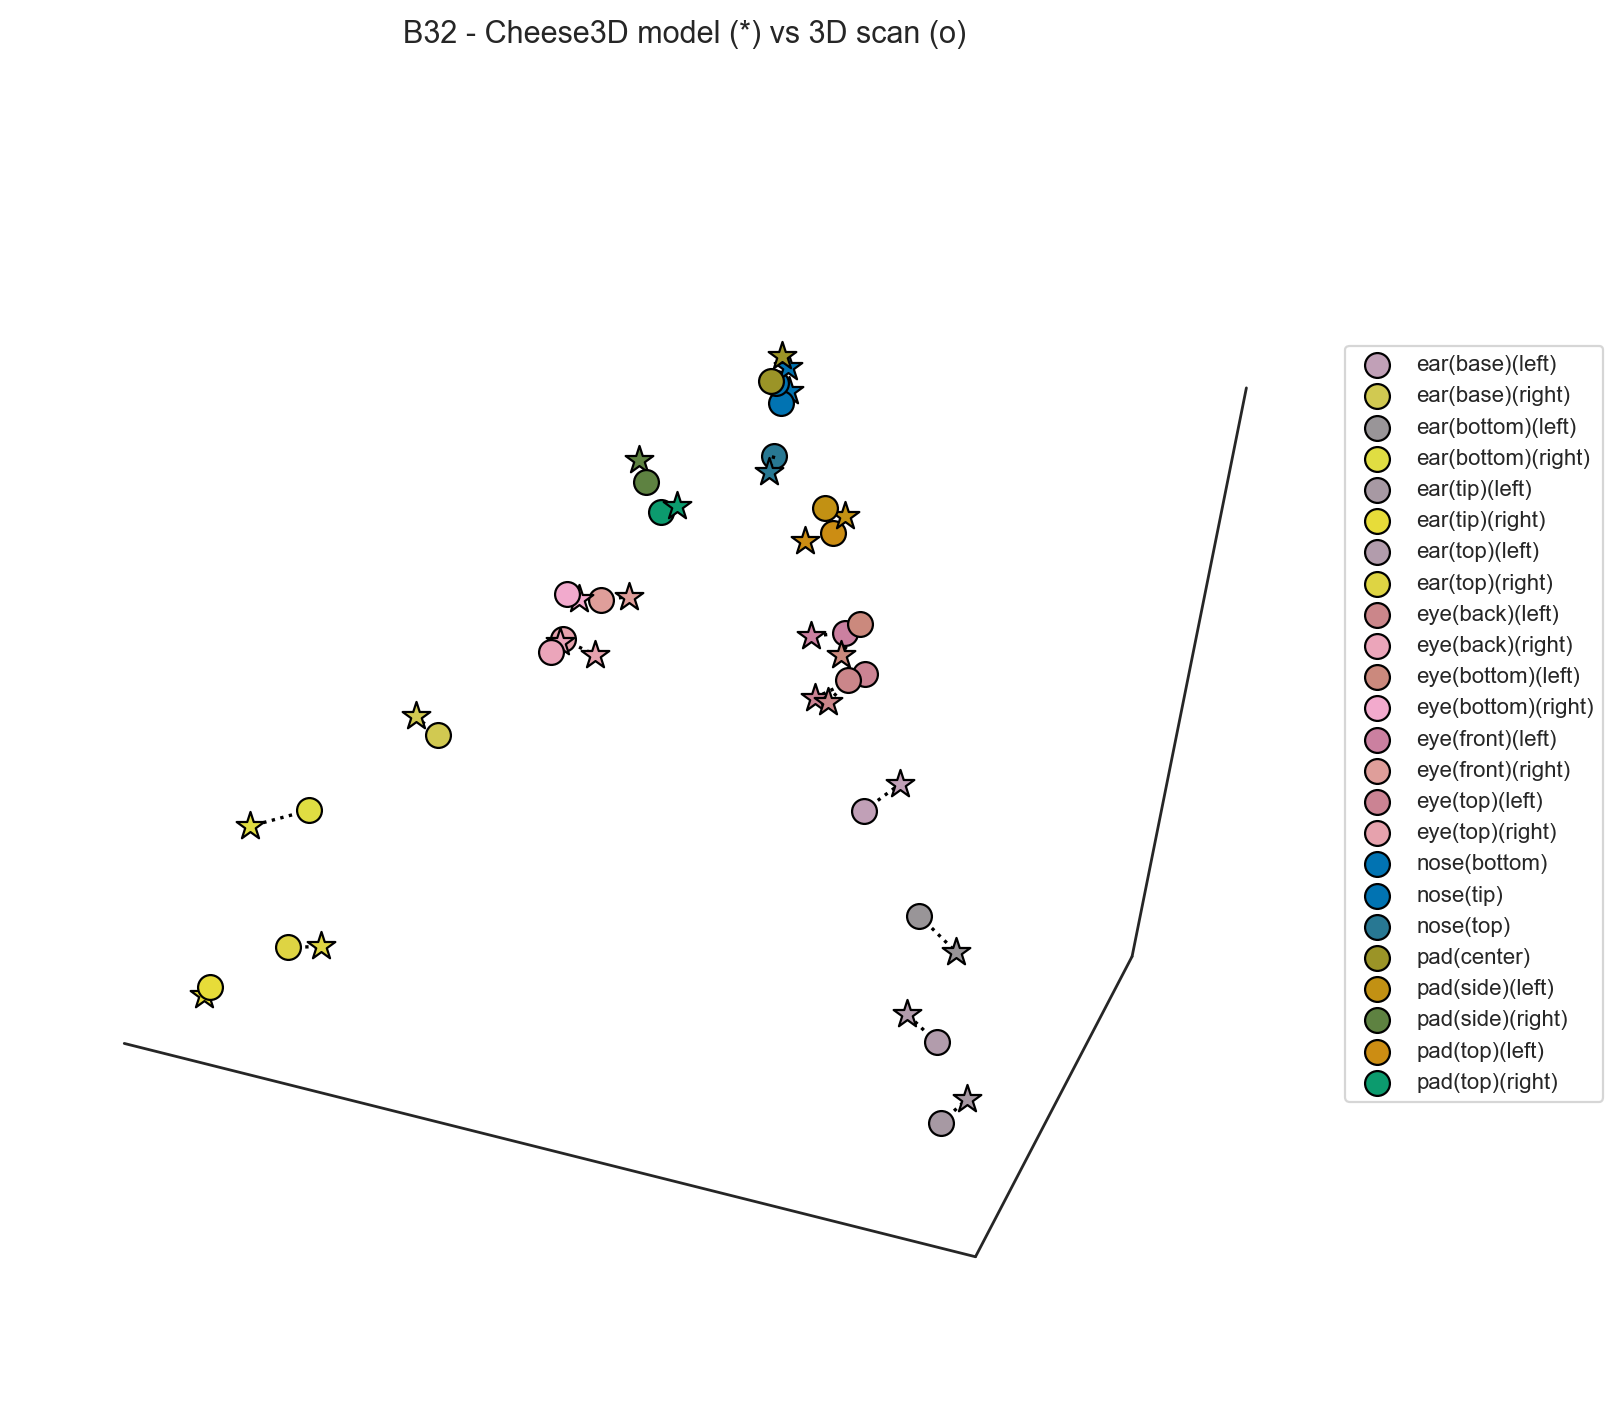

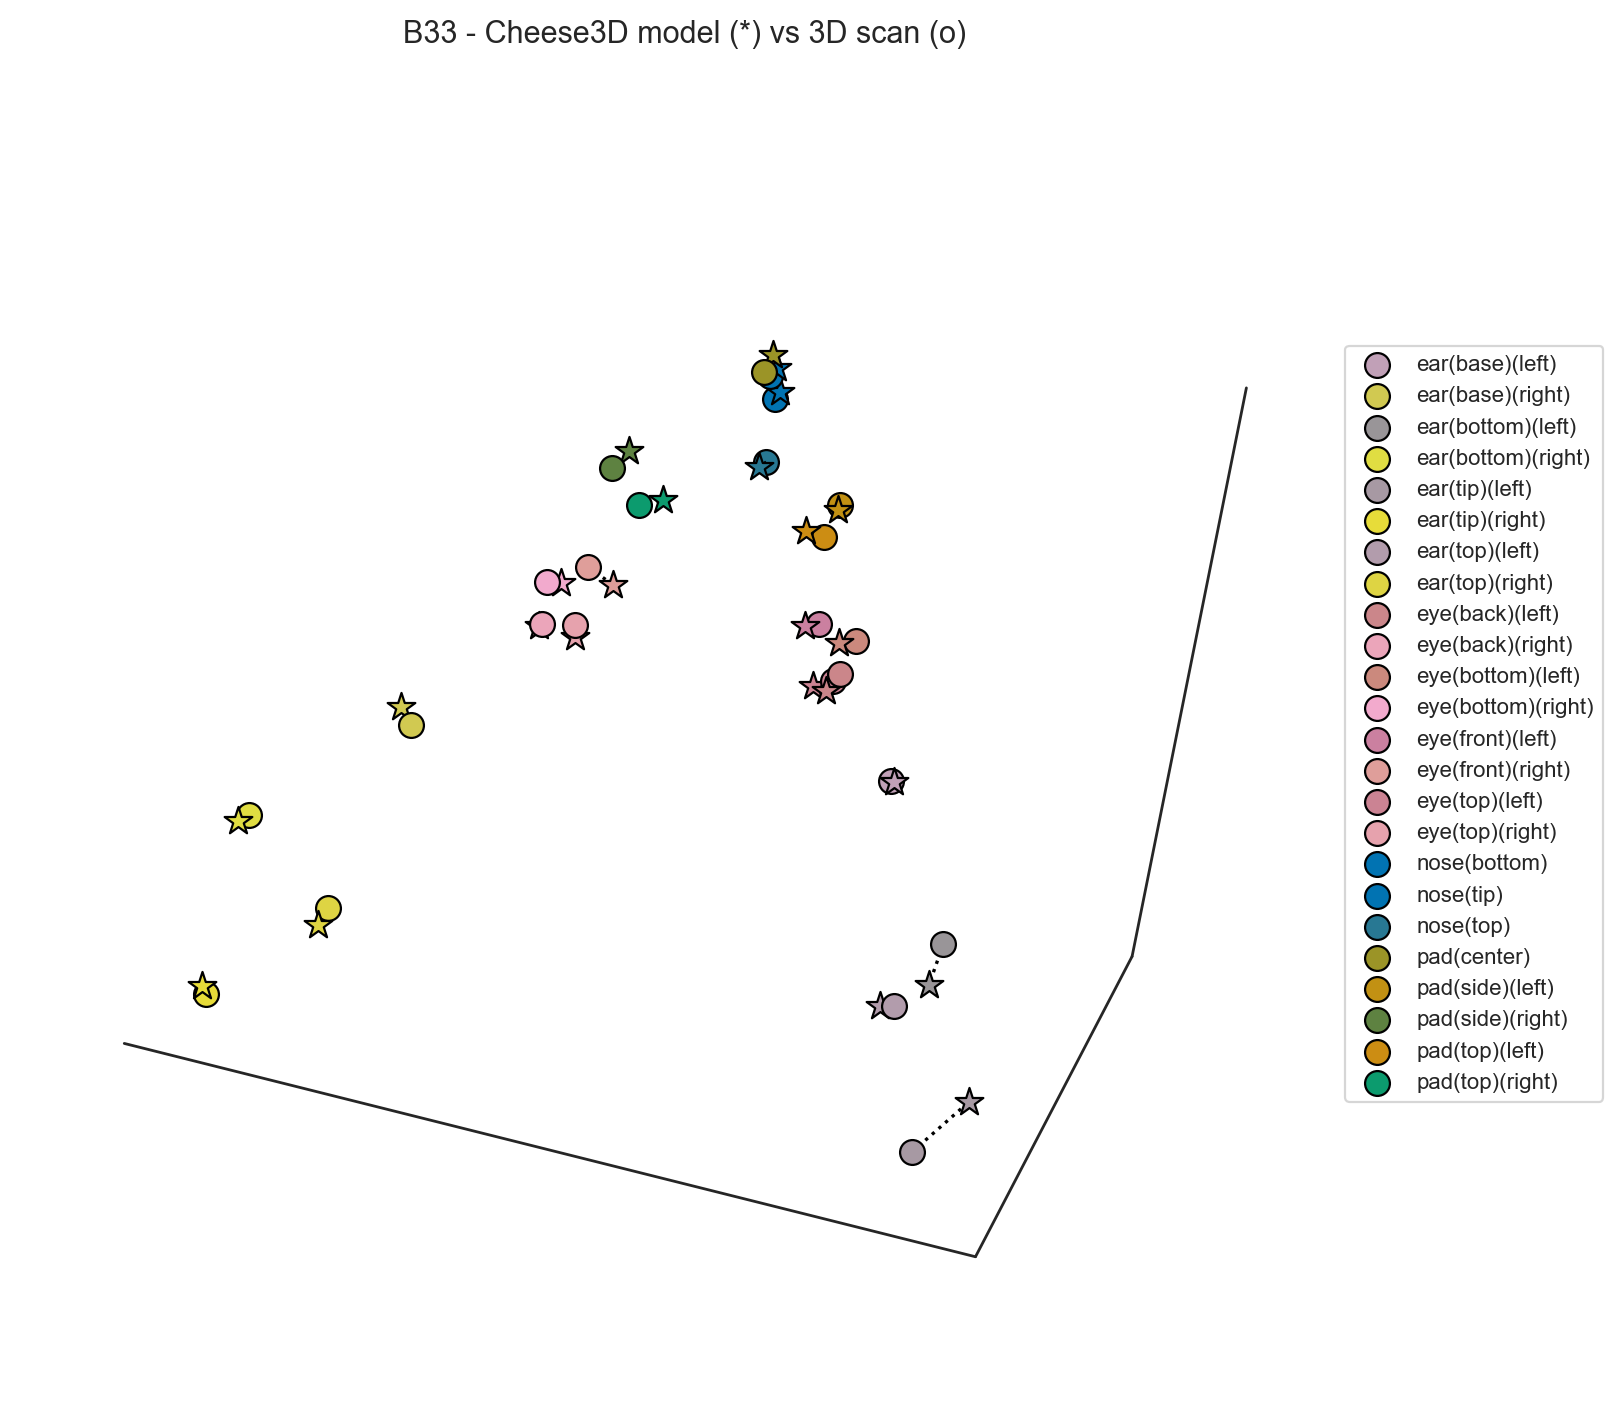

In [14]:
for mouse in MICE_SHORT:
    if mouse == 'B21':
        continue
    fig, axs = plot_scan_rig_comparison(scan_coords_mice_transform, rig_coords_mice_centered,
                                mouse, (20, 100, -10), excluded) #(20, 100, -10) - good angles for rig->3D scan transform
    # fig.savefig(f'figures/{mouse}_3Dmaping_scan2rig_Rig2vs3Dmesh.png')
    # fig.savefig(f'figures/{mouse}_3Dmaping_scan2rig_Rig2vs3Dmesh.svg')